# 01 Time Series Baseline Models (w/ Rolling Window OHLCV as Features)

## Imports

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import date
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import heatmap

import tulipy as ti

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras import initializers
import keras_tuner as kt
from keras_tuner import HyperParameters

import warnings

# Data Preprocessing and Feature Engineering
This is also done in a separate set of notebooks, but we will also keep the process here for continuity.

## Data Retrieval

In [2]:
# Set Scope of Date
start_date_analyzed = '2021-01-01'
end_date_analyzed = '2025-01-01'

# Retrieve S&P 500 tickers
sp500_tables = pd.read_html('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')
tickers = sp500_tables[0].Symbol  # Storing just the symbols into a list
tickers_changed = sp500_tables[1]  # Including the changed tickers as well to remove survivorship bias

# Getting only the added and removed tickers
tickers_added = tickers_changed[pd.to_datetime(tickers_changed.Date.Date) >= start_date_analyzed].Added
tickers_removed = tickers_changed[pd.to_datetime(tickers_changed.Date.Date) >= start_date_analyzed].Removed

# Removing the additional added tickers
tickers = tickers[~(tickers.isin(tickers_added.Ticker))]

# Appending the removed tickers
tickers = pd.concat([tickers, tickers_removed.Ticker], ignore_index=True)

# Dropping any NA values
tickers = tickers.dropna()

# Dropping duplicates
tickers = tickers.drop_duplicates()

# Resetting the index
tickers = tickers.reset_index(drop = True)

# Filtering out problematic tickers
problematic_tickers = ['BF.B', 'BRK.B', 'GEV', 'SOLV', 'SW', 'VLTO']
filtered_tickers = [ticker for ticker in tickers if ticker not in problematic_tickers]

len(filtered_tickers)

508

In [3]:
# One note: don't scrap too many times in a row from Yahoo Finance, or they might block you

In [4]:
# Getting Data for S&P500 Stocks
multi_data = yf.download(filtered_tickers, start=start_date_analyzed, end=end_date_analyzed)

# NOTE: there will be missing stocks because Yahoo Finance has delisted some of the stocks that went out of the S&P500 (like SIVB)
multi_data

[*********************100%***********************]  508 of 508 completed

26 Failed downloads:
['ATVI', 'NLSN', 'SIVB', 'ALXN', 'ABMD', 'FRC', 'DRE', 'CXO', 'KSU', 'MXIM', 'TWTR', 'CERN', 'MRO', 'FLIR', 'TIF', 'FBHS', 'PXD', 'PBCT', 'DISH', 'XLNX', 'HFC', 'VAR', 'GPS', 'CTXS']: YFTzMissingError('$%ticker%: possibly delisted; no timezone found')
['ETR', 'LEN']: YFPricesMissingError('$%ticker%: possibly delisted; no price data found  (1d 2021-01-01 -> 2025-01-01)')


Price      Adj Close                                            ... Volume  \
Ticker          ABMD ALXN ATVI CERN CTXS CXO DISH DRE ETR FBHS  ...   XLNX   
Date                                                            ...          
2021-01-04       NaN  NaN  NaN  NaN  NaN NaN  NaN NaN NaN  NaN  ...    NaN   
2021-01-05       NaN  NaN  NaN  NaN  NaN NaN  NaN NaN NaN  NaN  ...    NaN   
2021-01-06       NaN  NaN  NaN  NaN  NaN NaN  NaN NaN NaN  NaN  ...    NaN   
2021-01-07       NaN  NaN  NaN  NaN  NaN NaN  NaN NaN NaN  NaN  ...    NaN   
2021-01-08       NaN  NaN  NaN  NaN  NaN NaN  NaN NaN NaN  NaN  ...    NaN   
...              ...  ...  ...  ...  ...  ..  ...  ..  ..  ...  ...    ...   
2024-12-24       NaN  NaN  NaN  NaN  NaN NaN  NaN NaN NaN  NaN  ...    NaN   
2024-12-26       NaN  NaN  NaN  NaN  NaN NaN  NaN NaN NaN  NaN  ...    NaN   
2024-12-27       NaN  NaN  NaN  NaN  NaN NaN  NaN NaN NaN  NaN  ...    NaN   
2024-12-30       NaN  NaN  NaN  NaN  NaN NaN  NaN NaN NaN  NaN  ...    NaN   
2024-12-31       NaN  NaN  NaN  NaN  NaN NaN  NaN NaN NaN  NaN  ...    NaN   

Price                                                                      \
Ticker           XOM     XRAY      XRX      XYL      YUM      ZBH    ZBRA   
Date                                                                        
2021-01-04  27764700  2214500  1764900   814700  2058200  1265870  432600   
2021-01-05  44035100  3021700  1297800  1005200  1475300   998894  374700   
2021-01-06  36484800  1774700  2276900  1015300  1352700  1424799  419500   
2021-01-07  29528100  1334200  1737500  1539300  2222900  1237648  379900   
2021-01-08  28628200  1336100  1554800  1632200  1252200  1259072  348500   
...              ...      ...      ...      ...      ...      ...     ...   
2024-12-24   7807000   964900  2157000   379300   533000   458600   88700   
2024-12-26   9652400  2577100  2971100   575700  1040900  1277300  140100   
2024-12-27  11943900  1876900  1874700   552400  1146300   743400  287200   
2024-12-30  11080800  1965500  2120300   586800  1144600  1532000  211300   
2024-12-31  12387800  1595200  2035800   641600  1217100   683300  327900   

Price                         
Ticker         ZION      ZTS  
Date                          
2021-01-04  1625200  1805900  
2021-01-05  1349500  1358600  
2021-01-06  3269500  2139800  
2021-01-07  2333900  1710700  
2021-01-08  2201000  1475900  
...             ...      ...  
2024-12-24   371100  1023600  
2024-12-26  1158200  2167200  
2024-12-27   923400  1800100  
2024-12-30   827800  1531400  
2024-12-31  1426000  1327400  

[1005 rows x 2566 columns]

## Data Cleaning

In [5]:
# Dropping nulls based on column:
cleaned_multi_data = multi_data.dropna(axis=1)

cleaned_multi_data

Price            Close                                                 \
Ticker               A        AAL         AAP        AAPL        ABBV   
Date                                                                    
2021-01-04  115.582756  15.130000  143.031052  126.405251   88.933968   
2021-01-05  116.527748  15.430000  142.876526  127.968094   89.853607   
2021-01-06  119.723221  15.520000  151.130737  123.660477   89.077385   
2021-01-07  122.908966  15.380000  152.421600  127.880173   90.030762   
2021-01-08  123.785782  15.130000  154.594238  128.983978   90.503227   
...                ...        ...         ...         ...         ...   
2024-12-24  135.848907  17.350000   43.489883  257.916443  178.318420   
2024-12-26  135.579407  17.350000   43.997086  258.735504  177.525894   
2024-12-27  135.289932  17.350000   43.818073  255.309296  176.347015   
2024-12-30  134.171997  17.620001   45.797142  251.923019  174.553925   
2024-12-31  134.339996  17.430000   47.030334  250.144974  176.039917   

Price                                                                  ...  \
Ticker             ABT         ACN        ADBE         ADI        ADM  ...   
Date                                                                   ...   
2021-01-04  101.045967  242.118484  485.339996  136.015427  45.076885  ...   
2021-01-05  102.296181  243.496872  485.690002  138.446609  45.953655  ...   
2021-01-06  102.083199  246.159149  466.309998  139.070694  47.815678  ...   
2021-01-07  103.074104  248.481628  477.739990  144.948395  47.390835  ...   
2021-01-08  103.361191  249.387848  485.100006  146.000931  47.517391  ...   
...                ...         ...         ...         ...        ...  ...   
2024-12-24  114.160919  361.630005  447.940002  218.089996  50.630001  ...   
2024-12-26  114.668251  360.429993  450.160004  218.059998  50.610001  ...   
2024-12-27  114.389717  356.179993  446.480011  216.990005  50.580002  ...   
2024-12-30  112.211151  352.489990  445.799988  212.559998  50.070000  ...   
2024-12-31  112.519531  351.790009  444.679993  212.460007  50.520000  ...   

Price        Volume                                                         \
Ticker          XEL       XOM     XRAY      XRX      XYL      YUM      ZBH   
Date                                                                         
2021-01-04  3197100  27764700  2214500  1764900   814700  2058200  1265870   
2021-01-05  1976800  44035100  3021700  1297800  1005200  1475300   998894   
2021-01-06  2667000  36484800  1774700  2276900  1015300  1352700  1424799   
2021-01-07  2630400  29528100  1334200  1737500  1539300  2222900  1237648   
2021-01-08  2221500  28628200  1336100  1554800  1632200  1252200  1259072   
...             ...       ...      ...      ...      ...      ...      ...   
2024-12-24   943900   7807000   964900  2157000   379300   533000   458600   
2024-12-26  1394900   9652400  2577100  2971100   575700  1040900  1277300   
2024-12-27  2015000  11943900  1876900  1874700   552400  1146300   743400   
2024-12-30  2642900  11080800  1965500  2120300   586800  1144600  1532000   
2024-12-31  2143800  12387800  1595200  2035800   641600  1217100   683300   

Price                                 
Ticker        ZBRA     ZION      ZTS  
Date                                  
2021-01-04  432600  1625200  1805900  
2021-01-05  374700  1349500  1358600  
2021-01-06  419500  3269500  2139800  
2021-01-07  379900  2333900  1710700  
2021-01-08  348500  2201000  1475900  
...            ...      ...      ...  
2024-12-24   88700   371100  1023600  
2024-12-26  140100  1158200  2167200  
2024-12-27  287200   923400  1800100  
2024-12-30  211300   827800  1531400  
2024-12-31  327900  1426000  1327400  

[1005 rows x 2380 columns]

In [6]:
# Making cleaned_multi_data so that there are rows for each ticker for each date:
unstacked = cleaned_multi_data.stack(level=0).unstack(level=0)
unstacked = unstacked.transpose().reset_index()
unstacked.columns.name = None

unstacked

,Ticker,Date,Close,High,Low,Open,Volume
0,A,2021-01-04,115.582756,116.995388,114.092184,115.875028,2030700.0
1,A,2021-01-05,116.527748,117.219451,115.027432,115.426870,2344000.0
2,A,2021-01-06,119.723221,120.687707,115.163820,115.631454,2428500.0
3,A,2021-01-07,122.908966,124.194950,120.911790,121.126122,1775900.0
4,A,2021-01-08,123.785782,124.350838,122.606963,123.230471,1577200.0
...,...,...,...,...,...,...,...
478375,ZTS,2024-12-24,164.203583,164.542554,162.249499,163.206597,1023600.0
478376,ZTS,2024-12-26,165.021118,165.290293,162.528653,163.226540,2167200.0
478377,ZTS,2024-12-27,164.103897,166.028073,163.027150,164.452833,1800100.0
478378,ZTS,2024-12-30,161.751007,163.555549,160.963380,163.396028,1531400.0


In [7]:
# Getting Date to datetime format and setting as index
unstacked['Date'] = pd.to_datetime(unstacked['Date'])
data=unstacked.sort_values(by="Ticker",ascending=True)
data.set_index("Date",inplace=True)

# Re-ordering as OHLCV (industry standard) format
data = data[['Ticker', 'Open', 'High', 'Low', 'Close', 'Volume']]

data.head()

,Ticker,Open,High,Low,Close,Volume
Date,,,,,,
2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0
2023-08-22,A,116.605188,117.357163,116.090684,116.397408,1422300.0
2023-08-23,A,117.258235,117.891474,116.466682,117.871681,1289300.0
2023-08-24,A,118.099243,119.504242,117.327483,118.227867,2045900.0
2023-08-25,A,118.534606,119.543829,117.268120,118.415871,1273300.0


In [8]:
# Creating a new Date_col column to rank and drop dates appropriately
data = data.reset_index().set_index("Date", drop=False)
data = data.rename(columns={"Date": "Date_col"})
data["rank"] = data.groupby("Ticker")["Date_col"].rank()
data = data.sort_values(by=["Ticker", "Date_col"])

data

,Date_col,Ticker,Open,High,Low,Close,Volume,rank
Date,,,,,,,,
2021-01-04,2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0,1.0
2021-01-05,2021-01-05,A,115.426870,117.219451,115.027432,116.527748,2344000.0,2.0
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0
2021-01-08,2021-01-08,A,123.230471,124.350838,122.606963,123.785782,1577200.0,5.0
...,...,...,...,...,...,...,...,...
2024-12-24,2024-12-24,ZTS,163.206597,164.542554,162.249499,164.203583,1023600.0,1001.0
2024-12-26,2024-12-26,ZTS,163.226540,165.290293,162.528653,165.021118,2167200.0,1002.0
2024-12-27,2024-12-27,ZTS,164.452833,166.028073,163.027150,164.103897,1800100.0,1003.0


In [9]:
# Getting granular time series (gts) data for use later
data_gts = data.copy()
data_gts = data_gts[['Date_col', 'Ticker', 'rank', 'Open', 'High', 'Low', 'Close', 'Volume']]  # Just making sure we have all the features

## Feature Engineering

Outcome variables - Close price minus the Open price and variations of that

In [225]:
# Getting difference between close price and open price (outcome variables)
data["Close_Open_Diff"] = data["Close"] - data["Open"]
data["Close_Open_Diff_Perc"] = (data["Close"] - data["Open"]) / data["Open"] * 100

# Getting binary classification for whether a stock ended positive (1) or negative/zero (0)
data["Close_Open_Diff_Binary"] = data["Close_Open_Diff"] > 0

# Getting ternary classification for whether a stock ended positive (2), negative (0), or not much change (1)
close_open_conditions = [
    data['Close_Open_Diff_Perc'] > 0.5,       # Close price was at least 0.5% higher than Open price
    (data['Close_Open_Diff_Perc'] >= -0.5) &  # Close price was between -0.5% and 0.5% of Open price
        (data['Close_Open_Diff_Perc'] <= 0.5),
    data['Close_Open_Diff_Perc'] < -0.5       # Close price was at least 0.5% lower than Open price
]
close_open_choices = [2, 1, 0]  # Defining choices corresponding to conditions
data['Close_Open_Diff_Ternary'] = np.select(close_open_conditions, close_open_choices)  # Applying conditions

data

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,Close_Open_Diff_Binary,Close_Open_Diff_Ternary
Date,,,,,,,,,,,,
2021-01-04,2021-01-04,A,115.875021,116.995380,114.092176,115.582748,2030700.0,1.0,-0.292272,-0.252231,False,1
2021-01-05,2021-01-05,A,115.426893,117.219474,115.027454,116.527771,2344000.0,2.0,1.100878,0.953745,True,2
2021-01-06,2021-01-06,A,115.631469,120.687723,115.163835,119.723236,2428500.0,3.0,4.091767,3.538627,True,2
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0,1.782844,1.471891,True,2
2021-01-08,2021-01-08,A,123.230455,124.350822,122.606948,123.785767,1577200.0,5.0,0.555311,0.450628,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,2024-12-24,ZTS,163.206597,164.542554,162.249499,164.203583,1023600.0,1001.0,0.996986,0.610874,True,2
2024-12-26,2024-12-26,ZTS,163.226540,165.290293,162.528653,165.021118,2167200.0,1002.0,1.794578,1.099440,True,2
2024-12-27,2024-12-27,ZTS,164.452833,166.028073,163.027150,164.103897,1800100.0,1003.0,-0.348936,-0.212180,False,1


Getting previous day metrics (since we don't know current day's metrics except open) and growth rates

In [226]:
# Getting the first actual trading day
first_trading_date = str(data.Date_col.idxmin().date())

# Getting growth rates and previous day OHLCV metrics
for x in data.columns[2:-6]:
  data[f'Growth Rate_{x}'] = (data[x] - data[x].shift(1))/data[x].shift(1) * 100
data["PDO"] = data["Open"].shift(1)
data["PDH"] = data["High"].shift(1)
data["PDL"] = data["Low"].shift(1)
data["PDC"] = data["Close"].shift(1)
data["PDV"] = data["Volume"].shift(1)

# For row in data, if date is first trading date, set above column values to null. Note: date is the index:
data.loc[first_trading_date, ['PDO', 'PDH', 'PDL', 'PDC', 'PDV', 'Growth Rate_Open', 'Growth Rate_High', 'Growth Rate_Low',
    'Growth Rate_Close']] = np.nan

data

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,...,Close_Open_Diff_Ternary,Growth Rate_Open,Growth Rate_High,Growth Rate_Low,Growth Rate_Close,PDO,PDH,PDL,PDC,PDV
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,2021-01-04,A,115.875021,116.995380,114.092176,115.582748,2030700.0,1.0,-0.292272,-0.252231,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,2021-01-05,A,115.426893,117.219474,115.027454,116.527771,2344000.0,2.0,1.100878,0.953745,...,2,-0.386734,0.191541,0.819756,0.817616,115.875021,116.995380,114.092176,115.582748,2030700.0
2021-01-06,2021-01-06,A,115.631469,120.687723,115.163835,119.723236,2428500.0,3.0,4.091767,3.538627,...,2,0.177235,2.958765,0.118564,2.742235,115.426893,117.219474,115.027454,116.527771,2344000.0
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0,1.782844,1.471891,...,2,4.751866,2.906035,4.991111,2.660912,115.631469,120.687723,115.163835,119.723236,2428500.0
2021-01-08,2021-01-08,A,123.230455,124.350822,122.606948,123.785767,1577200.0,5.0,0.555311,0.450628,...,1,1.737308,0.125506,1.401979,0.713374,121.126122,124.194950,120.911790,122.908966,1775900.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,2024-12-24,ZTS,163.206597,164.542554,162.249499,164.203583,1023600.0,1001.0,0.996986,0.610874,...,2,-0.691580,-0.476397,0.006151,0.255660,164.343161,165.330182,162.239520,163.784851,2437800.0
2024-12-26,2024-12-26,ZTS,163.226540,165.290293,162.528653,165.021118,2167200.0,1002.0,1.794578,1.099440,...,2,0.012220,0.454435,0.172053,0.497879,163.206597,164.542554,162.249499,164.203583,1023600.0
2024-12-27,2024-12-27,ZTS,164.452833,166.028073,163.027150,164.103897,1800100.0,1003.0,-0.348936,-0.212180,...,1,0.751283,0.446354,0.306713,-0.555820,163.226540,165.290293,162.528653,165.021118,2167200.0


Getting gap (i.e., change from some previous day metric) features and volume features

In [227]:
# Getting the opening gap features from PDC
data["Gap_from_PDC"] = (data["Open"] - data["PDC"]) / data["PDC"]
gap_from_PDC_threshold = 0.02  # 2%
data["Gap_Binary_Threshold"] = abs(data["Gap_from_PDC"]) > gap_from_PDC_threshold

# Getting daily range gap up features
data["Daily_Range_Gap_Up"] = (data["Open"] - data["PDH"]) / data["PDH"]
data["Daily_Range_Gap_Up"] = data["Daily_Range_Gap_Up"].clip(lower = 0)
data["DR_Gap_Up_Binary"] = data["Daily_Range_Gap_Up"] > 0

# Getting daily range gap down features
data["Daily_Range_Gap_Down"] = (data["Open"] - data["PDL"]) / data["PDL"]
data["Daily_Range_Gap_Down"] = data["Daily_Range_Gap_Down"].clip(upper = 0)
data["DR_Gap_Down_Binary"] = data["Daily_Range_Gap_Down"] < 0

# Getting 14-day average volume and previous volume features
avg_vol_window = 14
data["Avg_Volume_14D"] = data["Volume"].rolling(window=avg_vol_window).mean()
data["Avg_Vol_Prev_14D"] = data["PDV"].rolling(window=avg_vol_window).mean()

# Comparing current volume to average volume over the past XX days
data["Vol_Change"] = (data["Volume"] - data["Avg_Vol_Prev_14D"]) / data["Avg_Vol_Prev_14D"]

# Setting the first 14-day volume averages and previous averages of every ticker to np.nan
data.loc[data["rank"] < 15, ["Avg_Volume_14D", "Avg_Vol_Prev_14D", "Vol_Change"]] = np.nan

data[10:20]

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,...,PDV,Gap_from_PDC,Gap_Binary_Threshold,Daily_Range_Gap_Up,DR_Gap_Up_Binary,Daily_Range_Gap_Down,DR_Gap_Down_Binary,Avg_Volume_14D,Avg_Vol_Prev_14D,Vol_Change
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-19,2021-01-19,A,124.097532,124.506714,123.035624,124.068306,1677200.0,11.0,-0.029226,-0.023551,...,2115400.0,0.009270,False,0.002045,True,0.000000,False,NaN,NaN,NaN
2021-01-20,2021-01-20,A,124.419030,125.597848,124.078050,124.808723,1843000.0,12.0,0.389694,0.313211,...,1677200.0,0.002827,False,0.000000,False,0.000000,False,NaN,NaN,NaN
2021-01-21,2021-01-21,A,124.477480,125.461455,123.162270,123.727325,1612100.0,13.0,-0.750155,-0.602643,...,1843000.0,-0.002654,False,0.000000,False,0.000000,False,NaN,NaN,NaN
2021-01-22,2021-01-22,A,123.805266,124.506713,123.045367,123.074593,1438700.0,14.0,-0.730673,-0.590179,...,1612100.0,0.000630,False,0.000000,False,0.000000,False,NaN,NaN,NaN
2021-01-25,2021-01-25,A,123.425309,124.194952,121.223545,122.246490,1365400.0,15.0,-1.178818,-0.955086,...,1438700.0,0.002850,False,0.000000,False,0.000000,False,1.728993e+06,1.776514e+06,-0.231416
2021-01-26,2021-01-26,A,122.265971,122.704372,120.677977,120.726685,1476600.0,16.0,-1.539287,-1.258966,...,1365400.0,0.000159,False,0.000000,False,0.000000,False,1.667036e+06,1.728993e+06,-0.145977
2021-01-27,2021-01-27,A,118.934116,119.830407,115.066418,115.738640,1923500.0,17.0,-3.195476,-2.686762,...,1476600.0,-0.014848,False,0.000000,False,-0.014451,True,1.630964e+06,1.667036e+06,0.153845
2021-01-28,2021-01-28,A,115.933492,119.508918,115.719160,118.427521,1677900.0,18.0,2.494029,2.151258,...,1923500.0,0.001684,False,0.000000,False,0.000000,False,1.623964e+06,1.630964e+06,0.028778
2021-01-29,2021-01-29,A,118.086512,118.554146,116.206246,117.073311,1822000.0,19.0,-1.013201,-0.858016,...,1677900.0,-0.002879,False,0.000000,False,0.000000,False,1.641450e+06,1.623964e+06,0.121946


Getting technical and momentum indicators

In [228]:
# SMA and EMA including this period
data["SMA_14"] = data["Close"].rolling(window=14).mean()
data["SMA_50"] = data["Close"].rolling(window=50).mean()
data["SMA_200"] = data["Close"].rolling(window=200).mean()
data["EMA_9"] = data["Close"].ewm(span=9, adjust=False).mean()
data["EMA_20"] = data["Close"].ewm(span=20, adjust=False).mean()

# SMA and EMA for the past XXX periods
data["SMA_prev_14"] = data["PDC"].rolling(window=14).mean()
data["SMA_prev_50"] = data["PDC"].rolling(window=50).mean()
data["SMA_prev_200"] = data["PDC"].rolling(window=200).mean()
data["EMA_prev_9"] = data["PDC"].ewm(span=9, adjust=False).mean()
data["EMA_prev_20"] = data["PDC"].ewm(span=20, adjust=False).mean()

# RSI Calculation
delta = data["Close"].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
data["RSI_14"] = 100 - (100 / (1 + rs))

# RSI for the previous XX periods using tulipy
rsi_prev_14 = ti.rsi(data["PDC"].to_numpy(), 14)
nan_array_rsi = np.full(14, np.nan)
rsi_prev_14 = np.concatenate((nan_array_rsi, rsi_prev_14))
data["RSI_prev_14"] = rsi_prev_14

# ATR Calculation
data["ATR_14"] = (data["PDH"] - data["PDL"]).rolling(window=14).mean()
data["NATR_14"] = (data["ATR_14"] / data["PDC"]) * 100

# Setting 9, 14, 20, 50, and 200 day metrics to np.nan:
data.loc[data["rank"] <= 9, ['EMA_9', 'EMA_prev_9']] = np.nan
data.loc[data["rank"] <= 14, ['SMA_14', 'SMA_prev_14', 'RSI_14', 'RSI_prev_14', 'ATR_14', 'NATR_14']] = np.nan
data.loc[data["rank"] <= 20, ['EMA_20', 'EMA_prev_20']] = np.nan
data.loc[data["rank"] <= 50, ['SMA_50', 'SMA_prev_50']] = np.nan
data.loc[data["rank"] <= 200, ['SMA_200', 'SMA_prev_200']] = np.nan

data[:18]

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,...,EMA_20,SMA_prev_14,SMA_prev_50,SMA_prev_200,EMA_prev_9,EMA_prev_20,RSI_14,RSI_prev_14,ATR_14,NATR_14
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,2021-01-04,A,115.875021,116.995380,114.092176,115.582748,2030700.0,1.0,-0.292272,-0.252231,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,2021-01-05,A,115.426893,117.219474,115.027454,116.527771,2344000.0,2.0,1.100878,0.953745,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-06,2021-01-06,A,115.631469,120.687723,115.163835,119.723236,2428500.0,3.0,4.091767,3.538627,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0,1.782844,1.471891,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-08,2021-01-08,A,123.230455,124.350822,122.606948,123.785767,1577200.0,5.0,0.555311,0.450628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-11,2021-01-11,A,123.191520,126.007047,122.977195,124.847710,1746800.0,6.0,1.656190,1.344403,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-12,2021-01-12,A,125.023052,125.081503,122.947935,123.698097,1826400.0,7.0,-1.324955,-1.059768,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-13,2021-01-13,A,124.175474,124.750274,123.474027,123.707848,1530400.0,8.0,-0.467627,-0.376585,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-14,2021-01-14,A,123.990362,124.886660,122.577731,122.782318,924900.0,9.0,-1.208044,-0.974305,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Getting sectors for stocks

In [230]:
# Getting the sector for stocks as another feature
ticker_and_sector = sp500_tables[0][['Symbol', 'GICS Sector']]

# Getting the GICS sector into the table through a merge function
data = data.reset_index().merge(ticker_and_sector, left_on='Ticker', right_on='Symbol', how='left').set_index('Date')
data = data.drop(columns=['Symbol'])

data

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,...,SMA_prev_14,SMA_prev_50,SMA_prev_200,EMA_prev_9,EMA_prev_20,RSI_14,RSI_prev_14,ATR_14,NATR_14,GICS Sector
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,2021-01-04,A,115.875021,116.995380,114.092176,115.582748,2030700.0,1.0,-0.292272,-0.252231,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
2021-01-05,2021-01-05,A,115.426893,117.219474,115.027454,116.527771,2344000.0,2.0,1.100878,0.953745,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
2021-01-06,2021-01-06,A,115.631469,120.687723,115.163835,119.723236,2428500.0,3.0,4.091767,3.538627,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0,1.782844,1.471891,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
2021-01-08,2021-01-08,A,123.230455,124.350822,122.606948,123.785767,1577200.0,5.0,0.555311,0.450628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,2024-12-24,ZTS,163.206597,164.542554,162.249499,164.203583,1023600.0,1001.0,0.996986,0.610874,...,172.467891,177.604711,175.450539,168.747011,172.143012,28.861416,30.117889,3.789973,2.313995,Health Care
2024-12-26,2024-12-26,ZTS,163.226540,165.290293,162.528653,165.021118,2167200.0,1002.0,1.794578,1.099440,...,171.711605,177.056477,175.363788,167.838326,171.386876,31.784154,31.300146,3.671758,2.236101,Health Care
2024-12-27,2024-12-27,ZTS,164.452833,166.028073,163.027150,164.103897,1800100.0,1003.0,-0.348936,-0.212180,...,171.052882,176.529766,175.291712,167.274884,170.780613,25.913882,33.659956,3.668909,2.223296,Health Care


In [231]:
# Getting date index column:
date_index = data.index.sort_values()

# Dropping duplicates:
date_index = date_index.drop_duplicates()

date_index

DatetimeIndex(['2021-01-04', '2021-01-05', '2021-01-06', '2021-01-07',
               '2021-01-08', '2021-01-11', '2021-01-12', '2021-01-13',
               '2021-01-14', '2021-01-15',
               ...
               '2024-12-17', '2024-12-18', '2024-12-19', '2024-12-20',
               '2024-12-23', '2024-12-24', '2024-12-26', '2024-12-27',
               '2024-12-30', '2024-12-31'],
              dtype='datetime64[ns]', name='Date', length=1005, freq=None)

# Time Series Rolling Window Models (w/ Rolling OHLCV Values as Features)
In this new set of models which attempts to incorporate the time-series aspect of our data, our new features will simply be the Open, High, Low, Close, and Volume (OHLCV) metrics of the past 14 days.* In other words, each day would have 70 features in this example, with the first 5 features being the OHLCV of the previous day**, the next 5 features being the OHCLV 2 days ago, etc. 

*We chose 14 since that's a common window range used in the industry, but this can be altered as well.

**We explain why we don't use current day metrics later, but it's essentially because we do not know those metrics until the current day has finished. Using them would create a huge unfair advantage for our model, as it would have information that we normally wouldn't have.

## Feature engineering with rolling window dates for OHLCV

### Initial feature engineering to obtain the rolling window dates

In [341]:
# Resetting data_gts to data_rwd for rolling window dates
data_rwd = data_gts.copy()

In [342]:
# Defining rolling window OHLCV data for previous XX days
days_back = 14

# Getting volume column to put back later (so as to not interfere with the ordering)
vol_col = data_rwd['Volume']

# Dropping volume column for now
data_rwd = data_rwd.drop('Volume', axis=1)

# Adding price columns based on rolling window dates (e.g., "Open minus 8" would be O_m_8)
for i in range(1, days_back+1):
    
    Open_m_X = "Open_m_" + str(i)
    High_m_X = "High_m_" + str(i)
    Low_m_X = "Low_m_" + str(i)
    Close_m_X = "Close_m_" + str(i)
    
    data_rwd[Open_m_X] = data["Open"].shift(i)
    data_rwd[High_m_X] = data["High"].shift(i)
    data_rwd[Low_m_X] = data["Low"].shift(i)
    data_rwd[Close_m_X] = data["Close"].shift(i)

# Getting number of columns to use in iloc later
num_cols_up_to_price = len(data_rwd.columns)

# Adding back volumn column
data_rwd['Volume'] = vol_col

# Adding volume columns based on rolling window dates (doing this after to put volume columns at the end)
for i in range(1, days_back+1):
    Volume_m_X = "Volume_m_" + str(i)
    data_rwd[Volume_m_X] = data["Volume"].shift(i)

# Getting total number of columns (including volume now) to use in iloc later
num_cols_up_to_volume = len(data_rwd.columns)

# If rank is less than or equal to the number of days back, drop the row (since there will be NaN data)
data_rwd = data_rwd[data_rwd['rank'] > days_back]

data_rwd

,Date_col,Ticker,rank,Open,High,Low,Close,Open_m_1,High_m_1,Low_m_1,...,Volume_m_5,Volume_m_6,Volume_m_7,Volume_m_8,Volume_m_9,Volume_m_10,Volume_m_11,Volume_m_12,Volume_m_13,Volume_m_14
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-25,2021-01-25,A,15.0,123.425324,124.194968,121.223560,122.246506,123.805281,124.506729,123.045382,...,2115400.0,924900.0,1530400.0,1826400.0,1746800.0,1577200.0,1775900.0,2428500.0,2344000.0,2030700.0
2021-01-26,2021-01-26,A,16.0,122.265994,122.704395,120.678000,120.726707,123.425324,124.194968,121.223560,...,1677200.0,2115400.0,924900.0,1530400.0,1826400.0,1746800.0,1577200.0,1775900.0,2428500.0,2344000.0
2021-01-27,2021-01-27,A,17.0,118.934108,119.830399,115.066411,115.738632,122.265994,122.704395,120.678000,...,1843000.0,1677200.0,2115400.0,924900.0,1530400.0,1826400.0,1746800.0,1577200.0,1775900.0,2428500.0
2021-01-28,2021-01-28,A,18.0,115.933484,119.508910,115.719152,118.427513,118.934108,119.830399,115.066411,...,1612100.0,1843000.0,1677200.0,2115400.0,924900.0,1530400.0,1826400.0,1746800.0,1577200.0,1775900.0
2021-01-29,2021-01-29,A,19.0,118.086527,118.554161,116.206261,117.073326,115.933484,119.508910,115.719152,...,1438700.0,1612100.0,1843000.0,1677200.0,2115400.0,924900.0,1530400.0,1826400.0,1746800.0,1577200.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,2024-12-24,ZTS,1001.0,163.206597,164.542554,162.249499,164.203583,164.343161,165.330182,162.239520,...,3018300.0,1938800.0,1650300.0,1936000.0,1782400.0,1678200.0,2387300.0,2551200.0,2442000.0,2687000.0
2024-12-26,2024-12-26,ZTS,1002.0,163.226540,165.290293,162.528653,165.021118,163.206597,164.542554,162.249499,...,2728300.0,3018300.0,1938800.0,1650300.0,1936000.0,1782400.0,1678200.0,2387300.0,2551200.0,2442000.0
2024-12-27,2024-12-27,ZTS,1003.0,164.452833,166.028073,163.027150,164.103897,163.226540,165.290293,162.528653,...,3713700.0,2728300.0,3018300.0,1938800.0,1650300.0,1936000.0,1782400.0,1678200.0,2387300.0,2551200.0


In [343]:
# Normalizing the OHLC for all dates to the most recent Open (by percent compared to Open price)
# ^i.e., if OHLC is 2, 3, 1, 4, respectively, then their normalized versions would be 1, 1.5, 0.5, 2, respectively
data_rwd.iloc[:, 3:num_cols_up_to_price] = data_rwd.iloc[:, 3:num_cols_up_to_price].div(data_rwd['Open'], axis=0)

# Normalizing volumes for all dates to the most recent volume (by percent compared to Volume)
data_rwd.iloc[:, num_cols_up_to_price:] = data_rwd.iloc[:, num_cols_up_to_price:].div(data_rwd['Volume'], axis=0)

data_rwd

,Date_col,Ticker,rank,Open,High,Low,Close,Open_m_1,High_m_1,Low_m_1,...,Volume_m_5,Volume_m_6,Volume_m_7,Volume_m_8,Volume_m_9,Volume_m_10,Volume_m_11,Volume_m_12,Volume_m_13,Volume_m_14
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-25,2021-01-25,A,15.0,1.0,1.006236,0.982161,0.990449,1.003078,1.008762,0.996922,...,1.549290,0.677384,1.120844,1.337630,1.279332,1.155119,1.300644,1.778600,1.716713,1.487256
2021-01-26,2021-01-26,A,16.0,1.0,1.003586,0.987012,0.987410,1.009482,1.015777,0.991474,...,1.135853,1.432615,0.626371,1.036435,1.236896,1.182988,1.068129,1.202695,1.644657,1.587431
2021-01-27,2021-01-27,A,17.0,1.0,1.007536,0.967480,0.973132,1.028015,1.031701,1.014663,...,0.958149,0.871952,1.099766,0.480842,0.795633,0.949519,0.908136,0.819964,0.923265,1.262542
2021-01-28,2021-01-28,A,18.0,1.0,1.030840,0.998151,1.021513,1.025882,1.033613,0.992521,...,0.960784,1.098397,0.999583,1.260743,0.551225,0.912092,1.088503,1.041063,0.939985,1.058406
2021-01-29,2021-01-29,A,19.0,1.0,1.003960,0.984077,0.991420,0.981767,1.012045,0.979952,...,0.789627,0.884797,1.011526,0.920527,1.161032,0.507629,0.839956,1.002415,0.958727,0.865642
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,2024-12-24,ZTS,1001.0,1.0,1.008186,0.994136,1.006109,1.006964,1.013012,0.994075,...,2.948710,1.894099,1.612251,1.891364,1.741305,1.639508,2.332259,2.492380,2.385698,2.625049
2024-12-26,2024-12-26,ZTS,1002.0,1.0,1.012643,0.995724,1.010994,0.999878,1.008062,0.994014,...,1.258906,1.392719,0.894611,0.761489,0.893319,0.822444,0.774363,1.101560,1.177187,1.126800
2024-12-27,2024-12-27,ZTS,1003.0,1.0,1.009579,0.991331,0.997878,0.992543,1.005092,0.988300,...,2.063052,1.515638,1.676740,1.077051,0.916782,1.075496,0.990167,0.932282,1.326204,1.417255


### Checking for NaN and infinite values
This is a step we should have done previously, but we're doing it now. In short, we need to make sure no NaN or infinite values exist in our data (potentially due to faulty downloading from the yfinance API). If we do have any, we should confirm what they are.

In [176]:
# One Volume NA value
data_test = data_rwd.iloc[:, 3:13]
data_test.isna().sum()

Open          0
High          0
Low           0
Close         0
Open_m_1      0
High_m_1      0
Low_m_1       0
Close_m_1     0
Volume        1
Volume_m_1    0
dtype: int64

In [115]:
# Finding the particular date that's the issue
data_test_v = data_rwd['Volume']
data_test_v[data_test_v.isna()]

Date
2023-06-09   NaN
Name: Volume, dtype: float64

In [116]:
# Finding the particular ticker that's the issue
data_test_small = data_rwd.loc['2023-06-09', ['Ticker', 'Volume']]
data_test_small.loc[data_test_small['Volume'].isna()]

,Ticker,Volume
Date,,
2023-06-09,BIIB,NaN


In [101]:
# We can also check for inf, and we see that there is also an inf value in Volume_m_1
data_test[data_test.isin([np.inf, -np.inf])].sum()

Open          0.0
High          0.0
Low           0.0
Close         0.0
Open_m_1      0.0
High_m_1      0.0
Low_m_1       0.0
Close_m_1     0.0
Volume        0.0
Volume_m_1    inf
dtype: float64

In [113]:
# Finding the particular date that's the issue
data_test_v1 = data_rwd['Volume_m_1']
data_test_v1[data_test_v1.isin([np.inf, -np.inf])]

Date
2023-06-09    inf
Name: Volume_m_1, dtype: float64

In [114]:
# Finding the particular ticker that's the issue
data_test_small = data_rwd.loc['2023-06-09', ['Ticker', 'Volume_m_1']]
data_test_small.loc[data_test_small['Volume_m_1'].isin([np.inf, -np.inf])]

,Ticker,Volume_m_1
Date,,
2023-06-09,BIIB,inf


In [109]:
# Checking to see this particular ticker in the original data
data_gts.loc[(data_gts['Ticker'] == 'BIIB') & (data_gts['Date_col'] == pd.to_datetime('2023-06-09'))]

,Date_col,Ticker,rank,Open,High,Low,Close,Volume
Date,,,,,,,,
2023-06-09,2023-06-09,BIIB,613.0,308.880005,308.880005,308.880005,308.880005,0.0


In [110]:
# Checking data around this ticker
data_gts.loc[(data_gts['Ticker'] == 'BIIB') & (data_gts['rank'] > 610) & (data_gts['rank'] < 616)]

,Date_col,Ticker,rank,Open,High,Low,Close,Volume
Date,,,,,,,,
2023-06-07,2023-06-07,BIIB,611.0,299.630005,309.299988,294.040009,304.899994,2034300.0
2023-06-08,2023-06-08,BIIB,612.0,310.690002,311.279999,303.690002,308.880005,1231600.0
2023-06-09,2023-06-09,BIIB,613.0,308.880005,308.880005,308.880005,308.880005,0.0
2023-06-12,2023-06-12,BIIB,614.0,319.760010,319.760010,310.000000,313.410004,1502500.0
2023-06-13,2023-06-13,BIIB,615.0,310.839996,312.760010,299.519989,304.600006,1526900.0


In [111]:
# Found that Biogen (BIIB) halted trading of common stock on 6/9/23 to review an application for a drug for Alzheimer's
# https://investors.biogen.com/news-releases/news-release-details/biogen-stock-trading-halted-today-fda-advisory-committee-review

In [118]:
# To resolve, we'll first see how many days are missing in the data in general to see if we can just remove this particular day:

### Testing for which days are missing in data
Because we're using rolling windows, we need to ensure that every stock exists with the same number of dates and values. If any are missing, it will cause the sequences to be misaligned, potentially messing up the model.

In [163]:
# Generating weekday dates within a specified date range
def get_weekday_dates(start_date, end_date):
  date_range = pd.date_range(start=start_date, end=end_date, freq='D')
  weekday_dates = date_range[date_range.weekday < 5]  # Monday to Friday
  weekend_dates = date_range[date_range.weekday >= 5]  # Saturday and Sunday
  return weekday_dates, weekend_dates

# Getting the weekday_dates starting from the start to the end date
start_date = '2021-01-01'
end_date = '2025-01-01'
weekday_dates, weekend_dates = get_weekday_dates(start_date, end_date)

# Checking to see if all dates are in the weekday dates
data_rwd_dates = data_rwd.index.unique()
print("Number of data_rwd dates not in weekday_dates:", (~data_rwd_dates.isin(weekday_dates)).sum())
print("Number of data_rwd dates in weekend_dates:", (data_rwd_dates.isin(weekend_dates)).sum(), '\n')

# Getting the number of weekdays missing
print("Number of weekday_dates not in data_rwd dates:", (~weekday_dates.isin(data_rwd_dates)).sum(), '\n')
print("Dates not included:", weekday_dates[~weekday_dates.isin(data_rwd_dates)])

Number of data_rwd dates not in weekday_dates: 0
Number of data_rwd dates in weekend_dates: 0 

Number of weekday_dates not in data_rwd dates: 40 

Dates not included: DatetimeIndex(['2021-01-01', '2021-01-04', '2021-01-18', '2021-02-15',
               '2021-04-02', '2021-05-31', '2021-07-05', '2021-09-06',
               '2021-11-25', '2021-12-24', '2022-01-17', '2022-02-21',
               '2022-04-15', '2022-05-30', '2022-06-20', '2022-07-04',
               '2022-09-05', '2022-11-24', '2022-12-26', '2023-01-02',
               '2023-01-16', '2023-02-20', '2023-04-07', '2023-05-29',
               '2023-06-19', '2023-07-04', '2023-09-04', '2023-11-23',
               '2023-12-25', '2024-01-01', '2024-01-15', '2024-02-19',
               '2024-03-29', '2024-05-27', '2024-06-19', '2024-07-04',
               '2024-09-02', '2024-11-28', '2024-12-25', '2025-01-01'],
              dtype='datetime64[ns]', freq=None)


In [171]:
# Naming the dates not included in the dataset
dates_not_included = weekday_dates[~weekday_dates.isin(data_rwd_dates)]

# Getting the fixed holiday dates
holiday_dates_new_years = ['2021-01-01', '2022-01-01', '2023-01-01', '2024-01-01', '2025-01-01']
holiday_dates_christmas = ['2021-12-25', '2022-12-25', '2023-12-25', '2024-12-25']
holiday_dates_july_4th = ['2021-07-04', '2022-07-04', '2023-07-04', '2024-07-04']
holiday_dates_fixed = holiday_dates_new_years + holiday_dates_christmas + holiday_dates_july_4th

# Filtering down dates_not_included
dates_not_included = dates_not_included[~dates_not_included.isin(holiday_dates_fixed)]

dates_not_included

DatetimeIndex(['2021-01-04', '2021-01-18', '2021-02-15', '2021-04-02',
               '2021-05-31', '2021-07-05', '2021-09-06', '2021-11-25',
               '2021-12-24', '2022-01-17', '2022-02-21', '2022-04-15',
               '2022-05-30', '2022-06-20', '2022-09-05', '2022-11-24',
               '2022-12-26', '2023-01-02', '2023-01-16', '2023-02-20',
               '2023-04-07', '2023-05-29', '2023-06-19', '2023-09-04',
               '2023-11-23', '2024-01-15', '2024-02-19', '2024-03-29',
               '2024-05-27', '2024-06-19', '2024-09-02', '2024-11-28'],
              dtype='datetime64[ns]', freq=None)

Now we need to figure out why the dates above are not included:

In [175]:
# We intentionally dropped first XX (default 14) trading days so we have the data, so that's no problem
intentionally_excluded_dates = ['2021-01-04', '2021-01-05', '2021-01-06', '2021-01-07', '2021-01-08',
                                '2021-01-11', '2021-01-12', '2021-01-13', '2021-01-14', '2021-01-15',
                                '2021-01-18', '2021-01-19', '2021-01-20', '2021-01-21']

# Getting the observed holiday dates (from NYSE)
holiday_dates_observed = ['2021-01-18', '2021-02-15', '2021-04-02', '2021-05-31', '2021-07-05', '2021-09-06', '2021-11-25', '2021-12-24',
            '2022-01-17', '2022-02-21', '2022-04-15', '2022-05-30', '2022-06-20', '2022-07-04', '2022-09-05', '2022-11-24', '2022-12-26',
            '2023-01-02', '2023-01-16', '2023-02-20', '2023-04-07', '2023-05-29', '2023-06-19', '2023-07-04', '2023-09-04', '2023-11-23',
                          '2024-01-15', '2024-02-19', '2024-03-29', '2024-05-27', '2024-06-19', '2024-07-04', '2024-09-02', '2024-11-28']
# https://ir.theice.com/press/news-details/2019/NYSE-Group-Announces-2020-2021-and-2022-Holiday-and-Early-Closings-Calendar/default.aspx
# https://ir.theice.com/press/news-details/2021/NYSE-Group-Announces-2022-2023-and-2024-Holiday-and-Early-Closings-Calendar/default.aspx
# https://ir.theice.com/press/news-details/2022/NYSE-Group-Announces-2023-2024-and-2025-Holiday-and-Early-Closings-Calendar/default.aspx
more_excluded_dates = intentionally_excluded_dates + holiday_dates_observed

# More filtering down dates_not_included
dates_not_included = dates_not_included[~dates_not_included.isin(more_excluded_dates)]

dates_not_included

DatetimeIndex([], dtype='datetime64[ns]', freq=None)

We have now confirmed that all the other dates excluded were excluded either intentionally or due to holidays. Therefore, for the missing date in BIIB, we should probably not remove that date entirely, as it will directly affect moving averages and prices. Removing the entire ticker (Biogen) is a better option, as we won't have to manipulate the data more and it would only exclude one medium/large-sized stock (Biogen is the 39th largest biopharma company by market cap as of 2/17/25 (https://companiesmarketcap.com/pharmaceuticals/largest-pharmaceutical-companies-by-market-cap/)). The last option would be to keep the OHLC prices and just take the average of the volumes for the previous day and the next day, as it would keep most things the same. However, that's still somewhat unrealistic, and it doesn't do a perfect job representing potential trends.

Therefore, we will opt to remove BIIB as a ticker, as it's only one ticker datapoint, and we have many more in the biopharma sector.

### Continued Feature Engineering
Per our conclusion from above, we will exclude BIIB (Biogen) as a ticker so we don't run into the problem of NaN or Inf values

In [344]:
# Removing BIIB ticker in general
data_rwd = data_rwd[data_rwd['Ticker'] != 'BIIB']

data_rwd

,Date_col,Ticker,rank,Open,High,Low,Close,Open_m_1,High_m_1,Low_m_1,...,Volume_m_5,Volume_m_6,Volume_m_7,Volume_m_8,Volume_m_9,Volume_m_10,Volume_m_11,Volume_m_12,Volume_m_13,Volume_m_14
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-25,2021-01-25,A,15.0,1.0,1.006236,0.982161,0.990449,1.003078,1.008762,0.996922,...,1.549290,0.677384,1.120844,1.337630,1.279332,1.155119,1.300644,1.778600,1.716713,1.487256
2021-01-26,2021-01-26,A,16.0,1.0,1.003586,0.987012,0.987410,1.009482,1.015777,0.991474,...,1.135853,1.432615,0.626371,1.036435,1.236896,1.182988,1.068129,1.202695,1.644657,1.587431
2021-01-27,2021-01-27,A,17.0,1.0,1.007536,0.967480,0.973132,1.028015,1.031701,1.014663,...,0.958149,0.871952,1.099766,0.480842,0.795633,0.949519,0.908136,0.819964,0.923265,1.262542
2021-01-28,2021-01-28,A,18.0,1.0,1.030840,0.998151,1.021513,1.025882,1.033613,0.992521,...,0.960784,1.098397,0.999583,1.260743,0.551225,0.912092,1.088503,1.041063,0.939985,1.058406
2021-01-29,2021-01-29,A,19.0,1.0,1.003960,0.984077,0.991420,0.981767,1.012045,0.979952,...,0.789627,0.884797,1.011526,0.920527,1.161032,0.507629,0.839956,1.002415,0.958727,0.865642
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,2024-12-24,ZTS,1001.0,1.0,1.008186,0.994136,1.006109,1.006964,1.013012,0.994075,...,2.948710,1.894099,1.612251,1.891364,1.741305,1.639508,2.332259,2.492380,2.385698,2.625049
2024-12-26,2024-12-26,ZTS,1002.0,1.0,1.012643,0.995724,1.010994,0.999878,1.008062,0.994014,...,1.258906,1.392719,0.894611,0.761489,0.893319,0.822444,0.774363,1.101560,1.177187,1.126800
2024-12-27,2024-12-27,ZTS,1003.0,1.0,1.009579,0.991331,0.997878,0.992543,1.005092,0.988300,...,2.063052,1.515638,1.676740,1.077051,0.916782,1.075496,0.990167,0.932282,1.326204,1.417255


In [314]:
# Checking that there are no more NaN or Inf values
data_test_2 = data_rwd.iloc[:, 3:]
print("Number of NaN values:", data_test_2.isna().sum().sum())
print("Number of Inf values:", data_test_2[data_test_2.isin([np.inf, -np.inf])].sum().sum())

Number of NaN values: 0
Number of Inf values: 0.0


In [345]:
# Getting some more potential outcome variables (binary and ternary close)

# Getting binary classification for whether a stock ended positive (1) or negative/zero (0)
data_rwd['Close_Open_Diff_Binary'] = data_rwd.loc[:, 'Close'] > 1

# Getting ternary classification for whether a stock ended positive (2), not much change (1), or negative (0)
close_open_conditions = [
    data_rwd['Close'] > 1.005,       # Close price was at least 0.5% higher than Open price
    (data_rwd['Close'] >= 0.995) &   # Close price was between -0.5% and 0.5% of Open price
        (data_rwd['Close'] <= 1.005),
    data_rwd['Close'] < 0.995        # Close price was at least 0.5% lower than Open price
]
close_open_choices = [2, 1, 0]  # Defining choices corresponding to conditions
data_rwd['Close_Open_Diff_Ternary'] = np.select(close_open_conditions, close_open_choices)  # Applying conditions

data_rwd.head(3)

/var/folders/7l/wmvnlgr934b3zwnq5s8bsrwm0000gn/T/ipykernel_49725/4025985652.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_rwd['Close_Open_Diff_Binary'] = data_rwd.loc[:, 'Close'] > 1
/var/folders/7l/wmvnlgr934b3zwnq5s8bsrwm0000gn/T/ipykernel_49725/4025985652.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_rwd['Close_Open_Diff_Ternary'] = np.select(close_open_conditions, close_open_choices)  # Applying conditions


,Date_col,Ticker,rank,Open,High,Low,Close,Open_m_1,High_m_1,Low_m_1,...,Volume_m_7,Volume_m_8,Volume_m_9,Volume_m_10,Volume_m_11,Volume_m_12,Volume_m_13,Volume_m_14,Close_Open_Diff_Binary,Close_Open_Diff_Ternary
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-25,2021-01-25,A,15.0,1.0,1.006236,0.982161,0.990449,1.003078,1.008762,0.996922,...,1.120844,1.337630,1.279332,1.155119,1.300644,1.778600,1.716713,1.487256,False,0
2021-01-26,2021-01-26,A,16.0,1.0,1.003586,0.987012,0.987410,1.009482,1.015777,0.991474,...,0.626371,1.036435,1.236896,1.182988,1.068129,1.202695,1.644657,1.587431,False,0
2021-01-27,2021-01-27,A,17.0,1.0,1.007536,0.967480,0.973132,1.028015,1.031701,1.014663,...,1.099766,0.480842,0.795633,0.949519,0.908136,0.819964,0.923265,1.262542,False,0


In [346]:
# Getting the sector for stocks as another feature
ticker_and_sector = sp500_tables[0][['Symbol', 'GICS Sector']]

# Getting the GICS sector into the table through a merge function
data_rwd = data_rwd.reset_index().merge(ticker_and_sector, left_on='Ticker', right_on='Symbol', how='left').set_index('Date')
data_rwd = data_rwd.drop(columns=['Symbol'])

# Replacing NaN GICS Sectors with Other
data_rwd['GICS Sector'] = data_rwd['GICS Sector'].fillna('Other')

data_rwd.head(3)

,Date_col,Ticker,rank,Open,High,Low,Close,Open_m_1,High_m_1,Low_m_1,...,Volume_m_8,Volume_m_9,Volume_m_10,Volume_m_11,Volume_m_12,Volume_m_13,Volume_m_14,Close_Open_Diff_Binary,Close_Open_Diff_Ternary,GICS Sector
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-25,2021-01-25,A,15.0,1.0,1.006236,0.982161,0.990449,1.003078,1.008762,0.996922,...,1.337630,1.279332,1.155119,1.300644,1.778600,1.716713,1.487256,False,0,Health Care
2021-01-26,2021-01-26,A,16.0,1.0,1.003586,0.987012,0.987410,1.009482,1.015777,0.991474,...,1.036435,1.236896,1.182988,1.068129,1.202695,1.644657,1.587431,False,0,Health Care
2021-01-27,2021-01-27,A,17.0,1.0,1.007536,0.967480,0.973132,1.028015,1.031701,1.014663,...,0.480842,0.795633,0.949519,0.908136,0.819964,0.923265,1.262542,False,0,Health Care


## Ternary logistic regression w/ rolling window dates model (one ticker)

### Getting appropriate data for 14-day rolling OHLCV model

In [322]:
# Just getting the AAPL stock (data_rwd_s for data_rwd "small")
data_rwd_s = data_rwd[data_rwd['Ticker'] == 'AAPL']

# Dropping unnecessary columns (keeping the features and potential outcome variables), and moving Close to the end as an outcome variable
data_rwd_Close = data_rwd_s['Close']
data_rwd_s = data_rwd_s.drop(['Date_col', 'Ticker', 'rank', 'High', 'Low', 'Close', 'Volume', 'GICS Sector'], axis=1)
data_rwd_s['Close'] = data_rwd_Close

data_rwd_s

,Open,Open_m_1,High_m_1,Low_m_1,Close_m_1,Open_m_2,High_m_2,Low_m_2,Close_m_2,Open_m_3,...,Volume_m_8,Volume_m_9,Volume_m_10,Volume_m_11,Volume_m_12,Volume_m_13,Volume_m_14,Close_Open_Diff_Binary,Close_Open_Diff_Ternary,Close
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-25,1.0,0.952541,0.977494,0.943734,0.972042,0.935206,0.976235,0.933739,0.956664,0.899280,...,0.583403,0.636910,0.667198,0.695242,0.983988,0.619655,0.909209,False,1,0.998951
2021-01-26,1.0,0.996309,1.010376,0.950836,0.995265,0.949025,0.973886,0.940251,0.968454,0.931755,...,0.900867,0.934552,1.020265,1.068783,1.113706,1.576248,0.992624,False,1,0.996936
2021-01-27,1.0,1.001185,1.006066,0.985637,0.998117,0.997490,1.011573,0.951962,0.996444,0.950150,...,0.640581,0.629327,0.652859,0.712736,0.746630,0.778012,1.101135,False,0,0.990448
2021-01-28,1.0,1.028024,1.034260,1.006379,1.018205,1.029243,1.034260,1.013259,1.026089,1.025444,...,0.782482,0.632598,0.621484,0.644723,0.703854,0.737326,0.768317,False,0,0.982583
2021-01-29,1.0,1.027167,1.045351,1.006405,1.009277,1.055952,1.062357,1.033719,1.045866,1.057204,...,0.511240,0.628640,0.508224,0.499295,0.517965,0.565471,0.592361,False,0,0.971509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,1.0,0.997182,1.000626,0.992015,0.999139,0.970840,0.998082,0.961642,0.996086,0.968727,...,1.410713,1.945616,1.588779,1.921660,1.586877,1.723022,1.910242,True,2,1.010607
2024-12-26,1.0,0.989543,1.000077,0.988768,1.000039,0.986754,0.990162,0.981641,0.988691,0.960688,...,1.217285,1.203414,1.659714,1.355313,1.639279,1.353690,1.469830,True,1,1.003215
2024-12-27,1.0,1.001396,1.008804,0.999224,1.004615,0.990924,1.001474,0.990149,1.001435,0.988132,...,1.220504,0.782790,0.773870,1.067300,0.871551,1.054159,0.870507,False,0,0.991312


In [318]:
# Getting only the rows without np.nan (there shouldn't be any, but just in case)
data_rwd_s = data_rwd_s.dropna()

# Getting length of full data_rwd_s
len_data_rwd_s = len(data_rwd_s)

len_data_rwd_s

991

### Getting X, Y data along with train/val/test splits

In [230]:
# Creating df for X and df for Y (choosing Close_Open_Diff_Ternary as the outcome variable)
df_X = data_rwd_s.iloc[:,:-3]
df_Y = data_rwd_s.loc[:,'Close_Open_Diff_Ternary']

df_X.head(3)

,Open,Open_m_1,High_m_1,Low_m_1,Close_m_1,Open_m_2,High_m_2,Low_m_2,Close_m_2,Open_m_3,...,Volume_m_5,Volume_m_6,Volume_m_7,Volume_m_8,Volume_m_9,Volume_m_10,Volume_m_11,Volume_m_12,Volume_m_13,Volume_m_14
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-25,1.0,0.952541,0.977494,0.943734,0.972042,0.935206,0.976235,0.933739,0.956664,0.899280,...,0.708060,0.572431,0.562374,0.583403,0.636910,0.667198,0.695242,0.983988,0.619655,0.909209
2021-01-26,1.0,0.996309,1.010376,0.950836,0.995265,0.949025,0.973886,0.940251,0.968454,0.931755,...,0.922418,1.134239,0.916976,0.900867,0.934552,1.020265,1.068783,1.113706,1.576248,0.992624
2021-01-27,1.0,1.001185,1.006066,0.985637,0.998117,0.997490,1.011573,0.951962,0.996444,0.950150,...,0.740675,0.644383,0.792356,0.640581,0.629327,0.652859,0.712736,0.746630,0.778012,1.101135


In [281]:
# Defining train/val/test splits
train_split = 0.8
val_split = 0.1
test_split = 0.1

train_indices = round(len_data_rwd_s * train_split)
val_indices = train_indices + round(len_data_rwd_s * val_split)

# Creating training, validation, and test datasets with the appropriate splits
X_train = df_X.iloc[:train_indices]
X_val = df_X.iloc[train_indices:val_indices]
X_test = df_X.iloc[val_indices:]
Y_train = df_Y.iloc[:train_indices]
Y_val = df_Y.iloc[train_indices:val_indices]
Y_test = df_Y.iloc[val_indices:]

print("Printing the shape of X_train:", X_train.shape)
print("Printing the shape of X_val:", X_val.shape)
print("Printing the shape of X_test:", X_test.shape)
print("Printing the shape of Y_train:", Y_train.shape)
print("Printing the shape of Y_val:", Y_val.shape)
print("Printing the shape of Y_test:", Y_test.shape)

Printing the shape of X_train: (793, 71)
Printing the shape of X_val: (99, 71)
Printing the shape of X_test: (99, 71)
Printing the shape of Y_train: (793,)
Printing the shape of Y_val: (99,)
Printing the shape of Y_test: (99,)


### Building and compiling multinomial logistic model with hidden layers

In [282]:
# Building a function to create and compile tf model
def build_log_hl_model(num_features,
                       n_classes,
                       hidden_layer_sizes=[],
                       learning_rate=0.01,
                       activation='relu',
                       optimizer='SGD',
                       metric='accuracy'):

  # Resetting tf for consistent results
  tf.keras.backend.clear_session()
  np.random.seed(0)
  tf.random.set_seed(0)

  # Building a model using tf Sequential
  model = tf.keras.Sequential()

  # Input layer
  model.add(tf.keras.Input(shape=(num_features,), name='Input'))

  # Hidden layers
  for idx, hidden_layer_size in enumerate(hidden_layer_sizes):
      model.add(tf.keras.layers.Dense(
          units = hidden_layer_size,
          activation = 'relu',
          name = 'Hidden'+str(idx)
      ))

  # Dropout layer
  model.add(tf.keras.layers.Dropout(rate=0.3, name='Dropout'))
    
  # Output layer
  model.add(tf.keras.layers.Dense(
      units = n_classes,
      activation = 'softmax',
      name = 'Output'
  ))

  # Setting optimizer and specific learning rate
  optimizer_class = getattr(tf.keras.optimizers, optimizer)
  optimizer_true = optimizer_class(learning_rate=learning_rate)

  # Compiling the model
  model.compile(
      optimizer = optimizer_true,
      loss = tf.keras.losses.SparseCategoricalCrossentropy(),
      metrics = [metric]
  )

  return model


#### Default model

In [283]:
tf.random.set_seed(1234)
np.random.seed(1234)

# Setting hyperparameters
hidden_layer_sizes = [8]
learning_rate = 0.0001
activation = 'relu'
optimizer = 'Adam'
metric = 'accuracy'
num_epochs = 10
batch_size = 32

# Building and compiling the model
model_log_hl = build_log_hl_model(num_features=X_train.shape[1],
                                  n_classes=3,
                                  hidden_layer_sizes=hidden_layer_sizes,
                                  learning_rate=learning_rate,
                                  activation=activation,
                                  optimizer=optimizer,
                                  metric=metric)
print(model_log_hl.summary())

# Training the model using the training dataset and passing the validation
# dataset for validation
model_log_hl_fit = model_log_hl.fit(
    x = X_train,
    y = Y_train,
    validation_data = [X_val, Y_val],
    epochs = num_epochs,
    batch_size = batch_size,
    verbose = 1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden0 (Dense)                 │ (None, 8)              │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout (Dropout)               │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 603 (2.36 KB)

 Trainable params: 603 (2.36 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3148 - loss: 1.6910 - val_accuracy: 0.3333 - val_loss: 1.4664
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3270 - loss: 1.5701 - val_accuracy: 0.2525 - val_loss: 1.3613
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3349 - loss: 1.4687 - val_accuracy: 0.2727 - val_loss: 1.2910
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3247 - loss: 1.3844 - val_accuracy: 0.2424 - val_loss: 1.2503
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3359 - loss: 1.3678 - val_accuracy: 0.2727 - val_loss: 1.2225
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3460 - loss: 1.3266 - val_accuracy: 0.2828 - val_loss: 1.2064
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3472 - loss: 1.2872 - val_accuracy: 0.2828 - val_loss: 1.1960
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3665 - loss: 1.3051 - val_accuracy: 0.2828 - val_

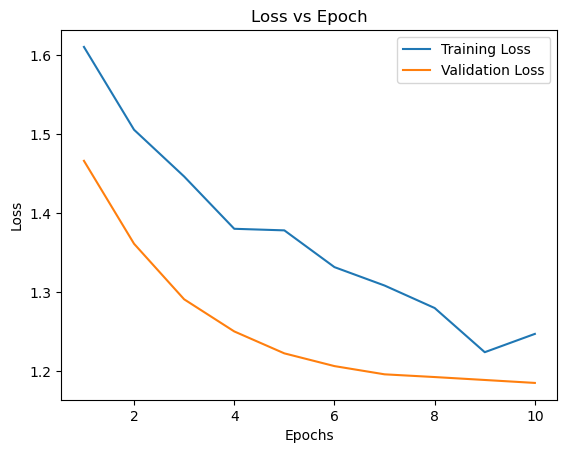

In [284]:
# Showing initial model on loss vs epoch plot
plt.rcdefaults()  # In case you changed this earlier
hist = model_log_hl_fit.history
plt.plot(range(1, num_epochs+1), hist['loss'], label='Training Loss')
plt.plot(range(1, num_epochs+1), hist['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.show()

#### Manual hyperparameter-tuned hidden layer model

In [303]:
tf.random.set_seed(1234)
np.random.seed(1234)

# Manually fine tuning the learning rate, number of epochs, and batch size
hidden_layer_sizes_m = [64, 16]
learning_rate_m = 0.000001
activation_m = 'relu'
optimizer_m = 'Adam'
metric_m = 'accuracy'
num_epochs_m = 25
batch_size_m = 64
model_log_hl_m = build_log_hl_model(num_features=X_train.shape[1],
                                    n_classes=3,
                                    hidden_layer_sizes=hidden_layer_sizes_m,
                                    learning_rate=learning_rate_m,
                                    activation=activation_m,
                                    optimizer=optimizer_m,
                                    metric=metric_m)
print(model_log_hl_m.summary())

# Training manual model
model_log_hl_fit_m = model_log_hl_m.fit(
    x = X_train,
    y = Y_train,
    validation_data = [X_val, Y_val],
    epochs = num_epochs_m,
    batch_size = batch_size_m,
    verbose = 0
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden0 (Dense)                 │ (None, 64)             │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden1 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,699 (22.26 KB)

 Trainable params: 5,699 (22.26 KB)

 Non-trainable params: 0 (0.00 B)

None


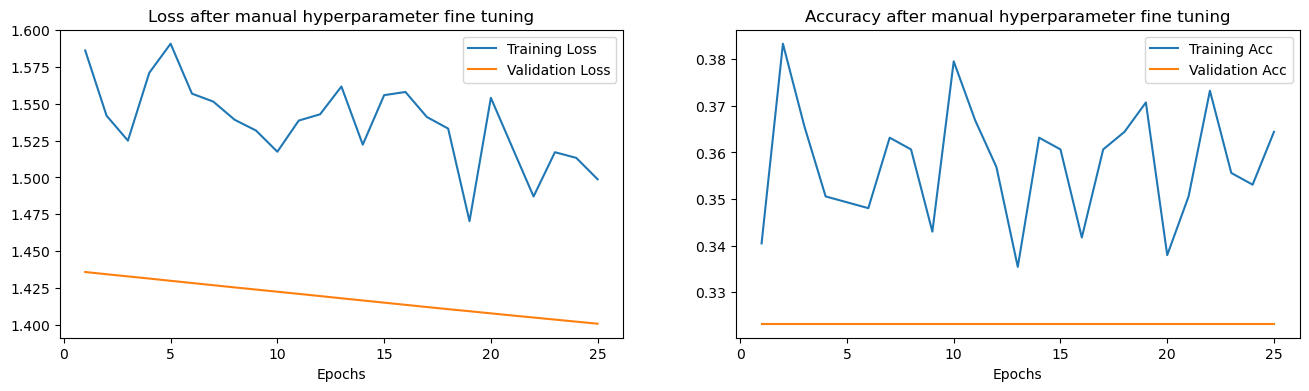

In [304]:
# Plotting the loss on the first subplot
hist_m = model_log_hl_fit_m.history
fig = plt.figure(figsize = (16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(range(1, num_epochs_m+1), hist_m['loss'], label='Training Loss')
plt.plot(range(1, num_epochs_m+1), hist_m['val_loss'], label='Validation Loss')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('Loss after manual hyperparameter fine tuning');

# Plotting the accuracy on the second subplot
ax = fig.add_subplot(1, 2, 2)
plt.plot(range(1, num_epochs_m+1), hist_m['accuracy'], label='Training Acc')
plt.plot(range(1, num_epochs_m+1), hist_m['val_accuracy'], label='Validation Acc')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('Accuracy after manual hyperparameter fine tuning')
plt.show()

In [305]:
# [DW] After man more attempts at manually tuning, this feels like a lost cause; will try moving onto multiple tickers to see if it
# can perform any better

## Ternary logistic regression w/ rolling window dates model (multiple tickers)

### Getting appropriate data for 14-day rolling OHLCV model

In [393]:
# Making a copy for all the tickers (data_rwd_a for data_rwd "all")
data_rwd_a = data_rwd.copy()

# Ordering by date, and then by ticker to get the right splits for train/val/test
data_rwd_a = data_rwd_a.sort_values(by=['Date_col', 'Ticker'])

# Dropping unnecessary columns (keeping the features and potential outcome variables), and moving Close to the end as an outcome variable
data_rwd_Close = data_rwd_a['Close']
data_rwd_a = data_rwd_a.drop(['Date_col', 'Ticker', 'rank', 'High', 'Low', 'Close', 'Volume'], axis=1)
data_rwd_a['Close'] = data_rwd_Close

data_rwd_a

,Open,Open_m_1,High_m_1,Low_m_1,Close_m_1,Open_m_2,High_m_2,Low_m_2,Close_m_2,Open_m_3,...,Volume_m_9,Volume_m_10,Volume_m_11,Volume_m_12,Volume_m_13,Volume_m_14,Close_Open_Diff_Binary,Close_Open_Diff_Ternary,GICS Sector,Close
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-25,1.0,1.003078,1.008762,0.996922,0.997158,1.008525,1.016497,0.997869,1.002447,1.008051,...,1.279332,1.155119,1.300644,1.778600,1.716713,1.487256,False,0,Health Care,0.990449
2021-01-25,1.0,1.003222,1.020619,0.996134,1.019330,1.030283,1.045103,1.002577,1.019974,1.041881,...,0.654437,0.898343,0.777795,1.028303,0.861410,1.125544,False,0,Other,0.994201
2021-01-25,1.0,1.011669,1.016923,0.996762,1.000489,1.008187,1.025049,1.008187,1.018329,1.014418,...,0.642250,0.468031,0.537708,0.857561,0.335391,0.459694,False,0,Other,0.975440
2021-01-25,1.0,0.952541,0.977494,0.943734,0.972042,0.935206,0.976235,0.933739,0.956664,0.899280,...,0.636910,0.667198,0.695242,0.983988,0.619655,0.909209,False,1,Information Technology,0.998951
2021-01-25,1.0,1.008384,1.017042,0.997722,1.010298,1.026428,1.027522,1.009387,1.013943,1.028980,...,0.914263,0.771615,1.182991,1.590240,0.984931,1.374585,True,2,Health Care,1.007017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,1.0,1.000298,1.002387,0.991871,0.995749,1.007831,1.017749,1.001492,1.008502,1.001939,...,1.859749,1.364144,0.858023,1.150029,1.115274,1.155369,True,1,Consumer Discretionary,1.000522
2024-12-31,1.0,1.001322,1.004154,0.988103,0.995185,1.002841,1.013958,1.001052,1.006798,1.008023,...,2.775501,2.510464,1.749305,1.768477,2.304990,1.726767,False,1,Health Care,0.997356
2024-12-31,1.0,1.004277,1.009233,0.986255,1.001121,1.025951,1.029419,1.009363,1.014736,1.023082,...,1.118024,0.931382,0.759988,0.791705,1.001830,1.071058,True,2,Information Technology,1.007303


In [394]:
# Getting only the rows without np.nan (there shouldn't be any, but just in case)
data_rwd_a = data_rwd_a.dropna()

# Getting length of full data_rwd_s
len_data_rwd_a = len(data_rwd_a)

len_data_rwd_a

470725

### Getting X, Y data along with train/val/test splits

In [395]:
# Creating df for X and df for Y (choosing Close_Open_Diff_Ternary as the outcome variable)
df_X = data_rwd_a.drop(['Close_Open_Diff_Binary', 'Close_Open_Diff_Ternary', 'Close'], axis=1)
df_Y = data_rwd_a.loc[:,'Close_Open_Diff_Ternary']

df_X.head(3)

,Open,Open_m_1,High_m_1,Low_m_1,Close_m_1,Open_m_2,High_m_2,Low_m_2,Close_m_2,Open_m_3,...,Volume_m_6,Volume_m_7,Volume_m_8,Volume_m_9,Volume_m_10,Volume_m_11,Volume_m_12,Volume_m_13,Volume_m_14,GICS Sector
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-25,1.0,1.003078,1.008762,0.996922,0.997158,1.008525,1.016497,0.997869,1.002447,1.008051,...,0.677384,1.120844,1.337630,1.279332,1.155119,1.300644,1.778600,1.716713,1.487256,Health Care
2021-01-25,1.0,1.003222,1.020619,0.996134,1.019330,1.030283,1.045103,1.002577,1.019974,1.041881,...,1.289671,0.688074,0.738322,0.654437,0.898343,0.777795,1.028303,0.861410,1.125544,Other
2021-01-25,1.0,1.011669,1.016923,0.996762,1.000489,1.008187,1.025049,1.008187,1.018329,1.014418,...,0.476314,0.476856,0.596070,0.642250,0.468031,0.537708,0.857561,0.335391,0.459694,Other


In [396]:
# Defining train/val/test splits
train_split = 0.8
val_split = 0.1
test_split = 0.1

train_indices = round(len_data_rwd_a * train_split)
val_indices = train_indices + round(len_data_rwd_a * val_split)

# Creating training, validation, and test datasets with the appropriate splits
X_train = df_X.iloc[:train_indices]
X_val = df_X.iloc[train_indices:val_indices]
X_test = df_X.iloc[val_indices:]
Y_train = df_Y.iloc[:train_indices]
Y_val = df_Y.iloc[train_indices:val_indices]
Y_test = df_Y.iloc[val_indices:]

print("Printing the shape of X_train:", X_train.shape)
print("Printing the shape of X_val:", X_val.shape)
print("Printing the shape of X_test:", X_test.shape)
print("Printing the shape of Y_train:", Y_train.shape)
print("Printing the shape of Y_val:", Y_val.shape)
print("Printing the shape of Y_test:", Y_test.shape)

Printing the shape of X_train: (376580, 72)
Printing the shape of X_val: (47072, 72)
Printing the shape of X_test: (47073, 72)
Printing the shape of Y_train: (376580,)
Printing the shape of Y_val: (47072,)
Printing the shape of Y_test: (47073,)


### Creating dummies for sector

In [397]:
# Getting train, val, and test dummy variables for GICS Sector
sector_train_d = pd.get_dummies(
    X_train['GICS Sector'],
    drop_first = False
)
sector_val_d = pd.get_dummies(
    X_val['GICS Sector'],
    drop_first = False
)
sector_test_d = pd.get_dummies(
    X_test['GICS Sector'],
    drop_first = False
)
print("Number of X_train dummy variables:", X_train['GICS Sector'].nunique())
print("Shape of X_train dummy variable for GICS Sector:",
      sector_train_d.shape, '\n')
print("Number of X_val dummy variables:", X_val['GICS Sector'].nunique())
print("Shape of X_val dummy variable for GICS Sector:",
      sector_val_d.shape, '\n')
print("Number of X_test dummy variables:", X_test['GICS Sector'].nunique())
print("Shape of X_test dummy variable for GICS Sector:",
      sector_test_d.shape, '\n')

# Adding the dummy variables to X_train, X_val, and X_test
X_train = pd.concat(
    [X_train, sector_train_d],
    axis=1
)
X_val = pd.concat(
    [X_val, sector_val_d],
    axis=1
)
X_test = pd.concat(
    [X_test, sector_test_d],
    axis=1
)


Number of X_train dummy variables: 12
Shape of X_train dummy variable for GICS Sector: (376580, 12) 

Number of X_val dummy variables: 12
Shape of X_val dummy variable for GICS Sector: (47072, 12) 

Number of X_test dummy variables: 12
Shape of X_test dummy variable for GICS Sector: (47073, 12) 



In [398]:
# Checking to make sure dummies were created correctly
X_train.head(3)

,Open,Open_m_1,High_m_1,Low_m_1,Close_m_1,Open_m_2,High_m_2,Low_m_2,Close_m_2,Open_m_3,...,Consumer Staples,Energy,Financials,Health Care,Industrials,Information Technology,Materials,Other,Real Estate,Utilities
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-25,1.0,1.003078,1.008762,0.996922,0.997158,1.008525,1.016497,0.997869,1.002447,1.008051,...,False,False,False,True,False,False,False,False,False,False
2021-01-25,1.0,1.003222,1.020619,0.996134,1.019330,1.030283,1.045103,1.002577,1.019974,1.041881,...,False,False,False,False,False,False,False,True,False,False
2021-01-25,1.0,1.011669,1.016923,0.996762,1.000489,1.008187,1.025049,1.008187,1.018329,1.014418,...,False,False,False,False,False,False,False,True,False,False


In [399]:
# Removing GICS Sector since we've converted it to one-hot encoding
X_train = X_train.drop("GICS Sector", axis = 1)
X_val = X_val.drop("GICS Sector", axis = 1)
X_test = X_test.drop("GICS Sector", axis = 1)

print("Shape of X_train after removing original GICS Sector feature:",
      X_train.shape)
print("Shape of X_val after removing original GICS Sector feature:",
      X_val.shape)
print("Shape of X_test after removing original GICS Sector feature:",
      X_test.shape)

Shape of X_train after removing original GICS Sector feature: (376580, 83)
Shape of X_val after removing original GICS Sector feature: (47072, 83)
Shape of X_test after removing original GICS Sector feature: (47073, 83)


### Building and compiling multinomial logistic model with hidden layers

In [401]:
# Building a function to create and compile tf model
def build_log_hl_model(num_features,
                       n_classes,
                       hidden_layer_sizes=[],
                       learning_rate=0.01,
                       activation='relu',
                       optimizer='SGD',
                       metric='accuracy'):

  # Resetting tf for consistent results
  tf.keras.backend.clear_session()
  np.random.seed(0)
  tf.random.set_seed(0)

  # Building a model using tf Sequential
  model = tf.keras.Sequential()

  # Input layer
  model.add(tf.keras.Input(shape=(num_features,), name='Input'))

  # Hidden layers
  for idx, hidden_layer_size in enumerate(hidden_layer_sizes):
      model.add(tf.keras.layers.Dense(
          units = hidden_layer_size,
          activation = 'relu',
          name = 'Hidden'+str(idx)
      ))

  # Dropout layer
  model.add(tf.keras.layers.Dropout(rate=0.3, name='Dropout'))
    
  # Output layer
  model.add(tf.keras.layers.Dense(
      units = n_classes,
      activation = 'softmax',
      name = 'Output'
  ))

  # Setting optimizer and specific learning rate
  optimizer_class = getattr(tf.keras.optimizers, optimizer)
  optimizer_true = optimizer_class(learning_rate=learning_rate)

  # Compiling the model
  model.compile(
      optimizer = optimizer_true,
      loss = tf.keras.losses.SparseCategoricalCrossentropy(),
      metrics = [metric]
  )

  return model


#### Default model

In [402]:
tf.random.set_seed(1234)
np.random.seed(1234)

# Setting hyperparameters
hidden_layer_sizes = [8]
learning_rate = 0.0001
activation = 'relu'
optimizer = 'Adam'
metric = 'accuracy'
num_epochs = 10
batch_size = 32

# Building and compiling the model
model_log_hl = build_log_hl_model(num_features=X_train.shape[1],
                                  n_classes=3,
                                  hidden_layer_sizes=hidden_layer_sizes,
                                  learning_rate=learning_rate,
                                  activation=activation,
                                  optimizer=optimizer,
                                  metric=metric)
print(model_log_hl.summary())

# Training the model using the training dataset and passing the validation
# dataset for validation
model_log_hl_fit = model_log_hl.fit(
    x = X_train,
    y = Y_train,
    validation_data = [X_val, Y_val],
    epochs = num_epochs,
    batch_size = batch_size,
    verbose = 1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden0 (Dense)                 │ (None, 8)              │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout (Dropout)               │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 699 (2.73 KB)

 Trainable params: 699 (2.73 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/10
11769/11769 ━━━━━━━━━━━━━━━━━━━━ 6s 455us/step - accuracy: 0.3535 - loss: 1.1795 - val_accuracy: 0.3557 - val_loss: 1.0925
Epoch 2/10
11769/11769 ━━━━━━━━━━━━━━━━━━━━ 6s 516us/step - accuracy: 0.3709 - loss: 1.0883 - val_accuracy: 0.3637 - val_loss: 1.0908
Epoch 3/10
11769/11769 ━━━━━━━━━━━━━━━━━━━━ 6s 535us/step - accuracy: 0.3736 - loss: 1.0872 - val_accuracy: 0.3645 - val_loss: 1.0903
Epoch 4/10
11769/11769 ━━━━━━━━━━━━━━━━━━━━ 6s 467us/step - accuracy: 0.3737 - loss: 1.0868 - val_accuracy: 0.3672 - val_loss: 1.0897
Epoch 5/10
11769/11769 ━━━━━━━━━━━━━━━━━━━━ 5s 464us/step - accuracy: 0.3736 - loss: 1.0868 - val_accuracy: 0.3614 - val_loss: 1.0909
Epoch 6/10
11769/11769 ━━━━━━━━━━━━━━━━━━━━ 5s 442us/step - accuracy: 0.3763 - loss: 1.0862 - val_accuracy: 0.3653 - val_loss: 1.0898
Epoch 7/10
11769/11769 ━━━━━━━━━━━━━━━━━━━━ 5s 458us/step - accuracy: 0.3735 - loss: 1.0862 - val_accuracy: 0.3632 - val_loss: 1.0903
Epoch 8/10
11769/11769 ━━━━━━━━━━━━━━━━━━━━ 5s 452us/step

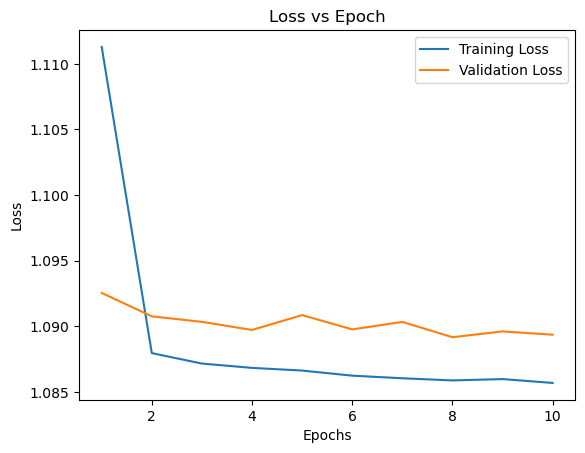

In [403]:
# Showing initial model on loss vs epoch plot
plt.rcdefaults()  # In case you changed this earlier
hist = model_log_hl_fit.history
plt.plot(range(1, num_epochs+1), hist['loss'], label='Training Loss')
plt.plot(range(1, num_epochs+1), hist['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.show()

#### Manual hyperparameter-tuned hidden layer model

In [410]:
tf.random.set_seed(1234)
np.random.seed(1234)

# Manually fine tuning the learning rate, number of epochs, and batch size
hidden_layer_sizes_m = [16, 8]
learning_rate_m = 0.0001
activation_m = 'relu'
optimizer_m = 'Adam'
metric_m = 'accuracy'
num_epochs_m = 25
batch_size_m = 1024
model_log_hl_m = build_log_hl_model(num_features=X_train.shape[1],
                                    n_classes=3,
                                    hidden_layer_sizes=hidden_layer_sizes_m,
                                    learning_rate=learning_rate_m,
                                    activation=activation_m,
                                    optimizer=optimizer_m,
                                    metric=metric_m)
print(model_log_hl_m.summary())

# Training manual model
model_log_hl_fit_m = model_log_hl_m.fit(
    x = X_train,
    y = Y_train,
    validation_data = [X_val, Y_val],
    epochs = num_epochs_m,
    batch_size = batch_size_m,
    verbose = 1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden0 (Dense)                 │ (None, 16)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout (Dropout)               │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,507 (5.89 KB)

 Trainable params: 1,507 (5.89 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/25
368/368 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3307 - loss: 1.1883 - val_accuracy: 0.3497 - val_loss: 1.0968
Epoch 2/25
368/368 ━━━━━━━━━━━━━━━━━━━━ 0s 868us/step - accuracy: 0.3613 - loss: 1.0959 - val_accuracy: 0.3500 - val_loss: 1.0947
Epoch 3/25
368/368 ━━━━━━━━━━━━━━━━━━━━ 0s 868us/step - accuracy: 0.3660 - loss: 1.0922 - val_accuracy: 0.3534 - val_loss: 1.0937
Epoch 4/25
368/368 ━━━━━━━━━━━━━━━━━━━━ 0s 897us/step - accuracy: 0.3682 - loss: 1.0906 - val_accuracy: 0.3578 - val_loss: 1.0928
Epoch 5/25
368/368 ━━━━━━━━━━━━━━━━━━━━ 0s 859us/step - accuracy: 0.3695 - loss: 1.0894 - val_accuracy: 0.3602 - val_loss: 1.0920
Epoch 6/25
368/368 ━━━━━━━━━━━━━━━━━━━━ 0s 876us/step - accuracy: 0.3709 - loss: 1.0889 - val_accuracy: 0.3628 - val_loss: 1.0915
Epoch 7/25
368/368 ━━━━━━━━━━━━━━━━━━━━ 0s 864us/step - accuracy: 0.3713 - loss: 1.0880 - val_accuracy: 0.3638 - val_loss: 1.0908
Epoch 8/25
368/368 ━━━━━━━━━━━━━━━━━━━━ 0s 859us/step - accuracy: 0.3740 - loss: 1.0873

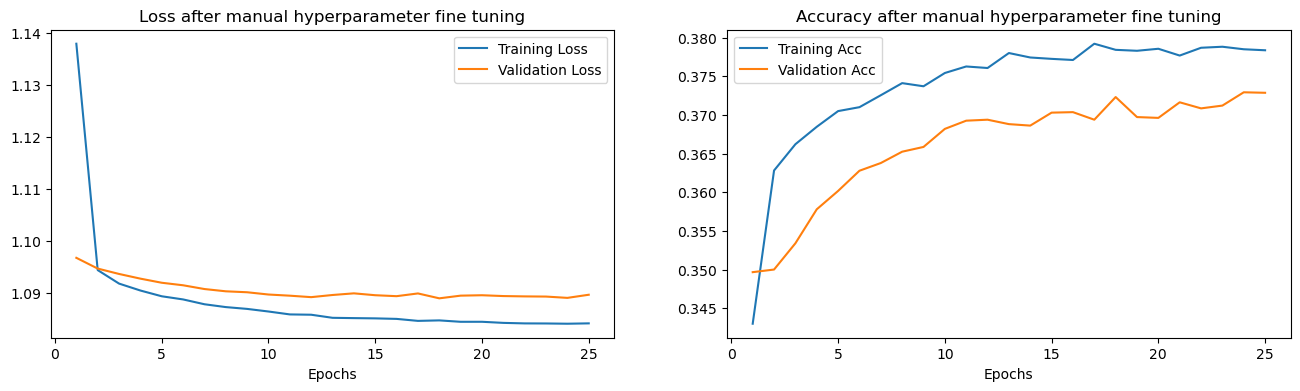

In [411]:
# Plotting the loss on the first subplot
hist_m = model_log_hl_fit_m.history
fig = plt.figure(figsize = (16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(range(1, num_epochs_m+1), hist_m['loss'], label='Training Loss')
plt.plot(range(1, num_epochs_m+1), hist_m['val_loss'], label='Validation Loss')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('Loss after manual hyperparameter fine tuning');

# Plotting the accuracy on the second subplot
ax = fig.add_subplot(1, 2, 2)
plt.plot(range(1, num_epochs_m+1), hist_m['accuracy'], label='Training Acc')
plt.plot(range(1, num_epochs_m+1), hist_m['val_accuracy'], label='Validation Acc')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('Accuracy after manual hyperparameter fine tuning')
plt.show()

In [412]:
# Clearly, this does not seem to be doing very much either, and our accuracy still can't get high at all.

## Conclusions for Time Series Rolling Window Models
Overall, our accuracies for the training and validation data are poor, and there's little point in continuing to measure the test accuracies. With this model, we forwent the derived features that we used in the previous model, and we focused solely on the OHLCV for the past 14 days. Whether it's because the model needs more time to learn from just those features, or it's because the base features alone are inherently not very valuable, we were unable to produce any meaningful results. Nevertheless, it was valuable going through this exercise to try and implement a "pseudo-time-series" model, and it gives us a good point of comparison for future models. The most promising model to try next would be the LSTM model, as it's a recurrent neural network designed specifically to keep track of useful information from past data.

One last consideration would be to try running these models with minute data. There seems to be too much variation in what can happen in a single day, and previous days' information may be trivial compared to all that happens during the current day. If we can get access to more granular 1-minute or 5-minute data, both this and future models can likely be improved immensely.